In [1]:
import torch
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Charger le dataset Breast Cancer Wisconsin
data = load_breast_cancer()
X = data.data  # Les caractéristiques des cellules
y = data.target # 0 = malin, 1 = bénin

# 2. Séparation des données (Apprentissage / Validation / Test)
# D'abord, on garde 70% pour l'apprentissage et 30% pour le reste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Ensuite, on coupe les 30% restants en deux : 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 3. Normalisation (Mettre toutes les valeurs à la même échelle)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Conversion au format Tensor de PyTorch (Indispensable pour le Deep Learning)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Super ! Données préparées avec succès.")
print(f"Taille des données d'apprentissage : {X_train_tensor.shape[0]} exemples")
print(f"Taille des données de validation : {X_val_tensor.shape[0]} exemples")
print(f"Taille des données de test : {X_test_tensor.shape[0]} exemples")

Super ! Données préparées avec succès.
Taille des données d'apprentissage : 398 exemples
Taille des données de validation : 85 exemples
Taille des données de test : 86 exemples


In [4]:
import torch.nn as nn

# 1. Définition des dimensions de notre réseau
input_dim = X_train_tensor.shape[1]  # 30 caractéristiques en entrée (taille, texture, etc.)
hidden_dim = 16                      # Nombre de neurones dans la couche cachée
output_dim = 1                       # 1 seule sortie car c'est une classification binaire (0 ou 1)

# ==========================================
# VERSION 1 : Le modèle avec nn.Sequential
# ==========================================
print("--- Architecture avec nn.Sequential ---")
model_sequential = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),                         # Fonction d'activation
    nn.Linear(hidden_dim, output_dim),
    nn.Sigmoid()                       # Pour obtenir une probabilité entre 0 et 1
)
print(model_sequential)


# ==========================================
# VERSION 2 : Le modèle avec Classe Personnalisée
# ==========================================
print("\n--- Architecture avec nn.Module (Classe personnalisée) ---")
class CustomMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CustomMLP, self).__init__()
        # On définit les "paramètres" du modèle ici
        self.couche1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.couche2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # On définit la "propagation avant" (l'ordre de passage des données)
        out = self.couche1(x)
        out = self.activation(out)
        out = self.couche2(out)
        out = self.sigmoid(out)
        return out

# On instancie notre modèle personnalisé
model_custom = CustomMLP(input_dim, hidden_dim, output_dim)
print(model_custom)

--- Architecture avec nn.Sequential ---
Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)

--- Architecture avec nn.Module (Classe personnalisée) ---
CustomMLP(
  (couche1): Linear(in_features=30, out_features=16, bias=True)
  (activation): ReLU()
  (couche2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [5]:
# ==========================================
# INSPECTION DES PARAMÈTRES DU MODÈLE
# ==========================================

print("1. Inspection avec named_parameters() :")
print("Cela nous montre le nom et la taille de chaque matrice de 'poids' et de 'biais'.\n")
for name, param in model_custom.named_parameters():
    print(f"Nom : {name} | Dimensions : {param.size()}")

print("\n--------------------------------------------------\n")

print("2. Inspection avec state_dict() :")
print("C'est le dictionnaire qui contient les vraies valeurs des paramètres (très utile pour sauvegarder le modèle plus tard !).\n")
for key in model_custom.state_dict().keys():
    print(f"Clé enregistrée : {key}")

1. Inspection avec named_parameters() :
Cela nous montre le nom et la taille de chaque matrice de 'poids' et de 'biais'.

Nom : couche1.weight | Dimensions : torch.Size([16, 30])
Nom : couche1.bias | Dimensions : torch.Size([16])
Nom : couche2.weight | Dimensions : torch.Size([1, 16])
Nom : couche2.bias | Dimensions : torch.Size([1])

--------------------------------------------------

2. Inspection avec state_dict() :
C'est le dictionnaire qui contient les vraies valeurs des paramètres (très utile pour sauvegarder le modèle plus tard !).

Clé enregistrée : couche1.weight
Clé enregistrée : couche1.bias
Clé enregistrée : couche2.weight
Clé enregistrée : couche2.bias


In [6]:
import torch.nn.init as init

# ==========================================
# FONCTIONS D'INITIALISATION
# ==========================================

# Fonction 1 : Initialisation Xavier & Constante
def init_weights_xavier(m):
    # On cible uniquement les couches linéaires (qui contiennent des poids)
    if isinstance(m, nn.Linear):
        # 1. Stratégie Xavier : Excellente pour éviter que les calculs n'explosent ou ne disparaissent
        init.xavier_uniform_(m.weight)
        # 2. Stratégie Constante : On initialise tous les biais à 0
        init.constant_(m.bias, 0)

# Fonction 2 : Initialisation Gaussienne (Loi normale)
def init_weights_gaussian(m):
    if isinstance(m, nn.Linear):
        # 3. Stratégie Gaussienne : Les poids suivent une courbe en cloche (Moyenne 0, écart-type 0.01)
        init.normal_(m.weight, mean=0.0, std=0.01)
        init.constant_(m.bias, 0)

# ==========================================
# APPLICATION AUX MODÈLES
# ==========================================

# On applique Xavier et Constante sur ton modèle personnalisé
model_custom.apply(init_weights_xavier)
print("Initialisation Xavier et Constante appliquées avec succès sur model_custom !")

# On applique la Gaussienne sur ton modèle séquentiel pour comparer plus tard
model_sequential.apply(init_weights_gaussian)
print("Initialisation Gaussienne appliquée avec succès sur model_sequential !")

Initialisation Xavier et Constante appliquées avec succès sur model_custom !
Initialisation Gaussienne appliquée avec succès sur model_sequential !


In [7]:
import torch

# ==========================================
# SAUVEGARDE DU MODÈLE
# ==========================================
# On définit le nom du fichier de sauvegarde
chemin_sauvegarde = "meilleur_modele_mlp.pth"

# On sauvegarde uniquement le dictionnaire des paramètres (state_dict)
torch.save(model_custom.state_dict(), chemin_sauvegarde)
print(f"✅ Modèle sauvegardé avec succès sous : {chemin_sauvegarde}")

# ==========================================
# RECHARGEMENT DU MODÈLE
# ==========================================
# 1. On instancie un réseau "vierge" avec exactement la même architecture
modele_recharge = CustomMLP(input_dim, hidden_dim, output_dim)

# 2. On charge le fichier physique et on l'injecte dans ce nouveau modèle
modele_recharge.load_state_dict(torch.load(chemin_sauvegarde, weights_only=True))

# 3. On passe le modèle en mode "évaluation" (bonne pratique avant de l'utiliser pour prédire)
modele_recharge.eval()
print("✅ Modèle rechargé avec succès depuis le fichier !")

✅ Modèle sauvegardé avec succès sous : meilleur_modele_mlp.pth
✅ Modèle rechargé avec succès depuis le fichier !


In [8]:
# 1. Détection automatique du meilleur périphérique disponible (GPU si activé, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Périphérique utilisé : {device}")

# 2. Envoi du modèle sur le périphérique
model_custom = model_custom.to(device)

# 3. Envoi de TOUTES nos données (tensors) sur le même périphérique
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

# 4. Vérification de la cohérence (Exigence du projet !)
print("\n--- VÉRIFICATION DE LA COHÉRENCE ---")
print(f"Emplacement du modèle (poids de la couche 1) : {next(model_custom.parameters()).device}")
print(f"Emplacement des données d'apprentissage : {X_train_tensor.device}")

if next(model_custom.parameters()).device == X_train_tensor.device:
    print(" COHÉRENCE OK : Le modèle et les données sont sur le même périphérique !")
else:
    print("ERREUR DE COHÉRENCE : Le modèle et les données ne sont pas au même endroit.")

Périphérique utilisé : cuda

--- VÉRIFICATION DE LA COHÉRENCE ---
Emplacement du modèle (poids de la couche 1) : cuda:0
Emplacement des données d'apprentissage : cuda:0
✅ COHÉRENCE OK : Le modèle et les données sont sur le même périphérique !


In [10]:
import torch.optim as optim

# 1. Définition des outils de calcul
criterion = nn.BCELoss() # Idéal pour la classification binaire
optimizer = optim.Adam(model_custom.parameters(), lr=0.01) # Taux d'apprentissage de 0.01

epochs = 100
print("Début de l'entraînement...\n")

for epoch in range(epochs):
    # --- PHASE D'APPRENTISSAGE ---
    model_custom.train() # On dit au modèle qu'il va s'entraîner

    # Prédire les résultats (Propagation avant)
    outputs = model_custom(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Rétropropagation du gradient (Backpropagation)
    optimizer.zero_grad() # On remet les compteurs à zéro
    loss.backward()       # On calcule les erreurs
    optimizer.step()      # On ajuste les poids et les biais

    # --- PHASE DE VALIDATION (Pour vérifier qu'il n'y a pas d'overfitting) ---
    model_custom.eval() # On passe en mode évaluation
    with torch.no_grad(): # On désactive le calcul des gradients pour économiser de la mémoire
        val_outputs = model_custom(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)

    # Affichage des scores tous les 10 tours
    if (epoch + 1) % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | Perte Entraînement : {loss.item():.4f} | Perte Validation : {val_loss.item():.4f}")

print("\nEntraînement terminé avec succès !")

Début de l'entraînement...

Époque [10/100] | Perte Entraînement : 0.0148 | Perte Validation : 0.1025
Époque [20/100] | Perte Entraînement : 0.0079 | Perte Validation : 0.1187
Époque [30/100] | Perte Entraînement : 0.0044 | Perte Validation : 0.1357
Époque [40/100] | Perte Entraînement : 0.0027 | Perte Validation : 0.1526
Époque [50/100] | Perte Entraînement : 0.0018 | Perte Validation : 0.1675
Époque [60/100] | Perte Entraînement : 0.0013 | Perte Validation : 0.1814
Époque [70/100] | Perte Entraînement : 0.0010 | Perte Validation : 0.1909
Époque [80/100] | Perte Entraînement : 0.0008 | Perte Validation : 0.2001
Époque [90/100] | Perte Entraînement : 0.0007 | Perte Validation : 0.2074
Époque [100/100] | Perte Entraînement : 0.0005 | Perte Validation : 0.2154

Entraînement terminé avec succès !



🎯 RÉSULTATS FINAUX SUR LE JEU DE TEST
Précision globale (Accuracy) : 97.67 %

Rapport de classification détaillé :

              precision    recall  f1-score   support

   Malin (0)       0.93      1.00      0.96        26
   Bénin (1)       1.00      0.97      0.98        60

    accuracy                           0.98        86
   macro avg       0.96      0.98      0.97        86
weighted avg       0.98      0.98      0.98        86



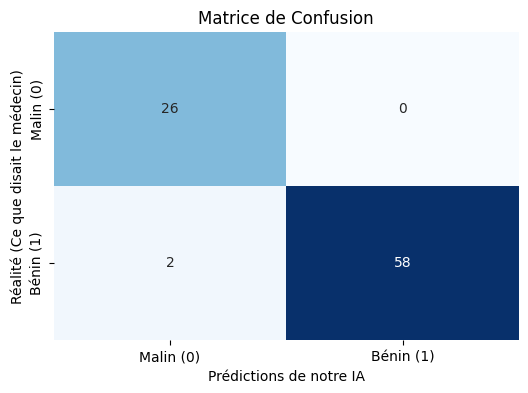

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. On passe le modèle en mode "évaluation"
model_custom.eval()

# 2. Prédictions sur l'ensemble de TEST secret
with torch.no_grad():
    # On fait passer les données de test dans le réseau
    test_outputs = model_custom(X_test_tensor)
    # Le modèle recrache des probabilités (ex: 0.8). On arrondit : >= 0.5 devient 1, sinon 0.
    predictions = (test_outputs >= 0.5).float()

# 3. Rapatriement des données (Scikit-Learn ne fonctionne que sur CPU !)
y_test_cpu = y_test_tensor.cpu().numpy()
predictions_cpu = predictions.cpu().numpy()

# 4. Calcul des scores finaux
accuracy = accuracy_score(y_test_cpu, predictions_cpu)
conf_matrix = confusion_matrix(y_test_cpu, predictions_cpu)

print("\n==================================================")
print("🎯 RÉSULTATS FINAUX SUR LE JEU DE TEST")
print("==================================================")
print(f"Précision globale (Accuracy) : {accuracy * 100:.2f} %\n")
print("Rapport de classification détaillé :\n")
print(classification_report(y_test_cpu, predictions_cpu, target_names=["Malin (0)", "Bénin (1)"]))

# 5. Affichage visuel de la Matrice de Confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Malin (0)", "Bénin (1)"],
            yticklabels=["Malin (0)", "Bénin (1)"])
plt.xlabel("Prédictions de notre IA")
plt.ylabel("Réalité (Ce que disait le médecin)")
plt.title("Matrice de Confusion")
plt.show()

# Partie 2 - CNN


In [12]:
import torch

# ==========================================
# IMPLÉMENTATION MANUELLE DE LA CORRÉLATION CROISÉE 2D
# ==========================================

def corr2d_manuelle(X, K):
    """
    Calcule la corrélation croisée 2D de manière manuelle.
    X : Matrice d'entrée (Image) de taille (H_in, W_in)
    K : Matrice du filtre (Kernel) de taille (h, w)
    """
    # 1. Récupération des dimensions du filtre
    h, w = K.shape

    # 2. Calcul des dimensions de la matrice de sortie
    h_out = X.shape[0] - h + 1
    w_out = X.shape[1] - w + 1

    # 3. Création d'une matrice de sortie remplie de zéros
    Y = torch.zeros((h_out, w_out))

    # 4. Double boucle pour faire glisser le filtre sur l'image
    for i in range(h_out):
        for j in range(w_out):
            # Extraction de la zone d'intérêt (fenêtre de la taille du filtre)
            zone_interet = X[i:i + h, j:j + w]

            # Multiplication élément par élément et somme globale
            Y[i, j] = (zone_interet * K).sum()

    return Y

# ==========================================
# TEST DE VÉRIFICATION
# ==========================================

# Simulation d'une petite image 3x3
X_test = torch.tensor([[0.0, 1.0, 2.0],
                       [3.0, 4.0, 5.0],
                       [6.0, 7.0, 8.0]])

# Simulation d'un filtre 2x2
K_test = torch.tensor([[0.0, 1.0],
                       [2.0, 3.0]])

# Exécution de notre fonction
resultat = corr2d_manuelle(X_test, K_test)

print("--- Test de l'implémentation manuelle ---")
print("Matrice d'entrée (Image 3x3) :\n", X_test)
print("\nFiltre (Kernel 2x2) :\n", K_test)
print("\nRésultat de la corrélation croisée (Sortie 2x2) :\n", resultat)

--- Test de l'implémentation manuelle ---
Matrice d'entrée (Image 3x3) :
 tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

Filtre (Kernel 2x2) :
 tensor([[0., 1.],
        [2., 3.]])

Résultat de la corrélation croisée (Sortie 2x2) :
 tensor([[19., 25.],
        [37., 43.]])


In [13]:
# ==========================================
# IMPLÉMENTATION MANUELLE DU POOLING 2D
# ==========================================

def pooling2d_manuel(X, pool_size=(2, 2), mode='max'):
    """
    Calcule le pooling 2D (Max ou Average) sans chevauchement (stride = pool_size).
    X : Matrice d'entrée de taille (H_in, W_in)
    pool_size : Taille de la fenêtre de pooling (hauteur, largeur)
    mode : 'max' pour le Max-Pooling, 'avg' pour l'Average-Pooling
    """
    ph, pw = pool_size

    # Calcul des dimensions de la matrice de sortie (sans chevauchement)
    h_out = X.shape[0] // ph
    w_out = X.shape[1] // pw

    Y = torch.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            # Définition de la fenêtre locale
            zone_interet = X[i*ph:(i+1)*ph, j*pw:(j+1)*pw]

            # Choix de l'opération selon le mode choisi
            if mode == 'max':
                Y[i, j] = zone_interet.max()
            elif mode == 'avg':
                Y[i, j] = zone_interet.mean()

    return Y

# ==========================================
# TEST DE VÉRIFICATION SUR UNE IMAGE 4x4
# ==========================================

# Création d'une image simulée 4x4
X_pool_test = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                             [5.0, 6.0, 7.0, 8.0],
                             [9.0, 10.0, 11.0, 12.0],
                             [13.0, 14.0, 15.0, 16.0]])

res_max = pooling2d_manuel(X_pool_test, pool_size=(2, 2), mode='max')
res_avg = pooling2d_manuel(X_pool_test, pool_size=(2, 2), mode='avg')

print("--- Test de l'implémentation du Pooling ---")
print("Image d'entrée 4x4 :\n", X_pool_test)
print("\nRésultat Max-Pooling 2x2 (Prend le maximum de chaque bloc) :\n", res_max)
print("\nRésultat Average-Pooling 2x2 (Prend la moyenne de chaque bloc) :\n", res_avg)

--- Test de l'implémentation du Pooling ---
Image d'entrée 4x4 :
 tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

Résultat Max-Pooling 2x2 (Prend le maximum de chaque bloc) :
 tensor([[ 6.,  8.],
        [14., 16.]])

Résultat Average-Pooling 2x2 (Prend la moyenne de chaque bloc) :
 tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])


In [14]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Définition de la transformation : Convertir l'image en Tensor et normaliser les pixels entre -1 et 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Téléchargement des données d'apprentissage et de test
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 3. Création des DataLoaders (Chargement des données par lots / batches de 64 images)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"✅ Dataset chargé !")
print(f"Nombre d'images d'entraînement : {len(train_dataset)}")
print(f"Nombre d'images de test : {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 5.85MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 62.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]


✅ Dataset chargé !
Nombre d'images d'entraînement : 60000
Nombre d'images de test : 10000


In [15]:
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# ARCHITECTURE DU MODÈLE CNN FINALE
# ==========================================

class MonCNN(nn.Module):
    def __init__(self):
        super(MonCNN, self).__init__()
        # Couche de convolution 1 : entrée=1 canal (gris), sortie=16 filtres, filtre=3x3, padding=1 (garde la taille)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Couche de pooling 1 : fenêtre 2x2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Couche de convolution 2 : entrée=16 filtres, sortie=32 filtres, filtre=3x3, padding=1
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Couche fully-connected (dense) : l'image originale 28x28 est passée par 2 poolings (28 -> 14 -> 7)
        # On a 32 filtres de taille 7x7 = 32 * 7 * 7 = 1568 entrées. Sortie = 10 classes.
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # Passage dans le premier bloc : Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Passage dans le deuxième bloc : Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Aplatissement des dimensions (Flatten) pour la couche dense, sauf la dimension du lot (batch)
        x = x.view(-1, 32 * 7 * 7)

        # Sortie brute (Logits) pour les 10 classes
        x = self.fc(x)
        return x

# Instanciation du modèle et envoi sur le périphérique (GPU/CPU)
modele_cnn = MonCNN().to(device)
print("--- Structure de ton réseau CNN ---")
print(modele_cnn)

--- Structure de ton réseau CNN ---
MonCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


In [16]:
import torch.optim as optim

# 1. Définition des outils de calcul
critere_cnn = nn.CrossEntropyLoss()
optimiseur_cnn = optim.Adam(modele_cnn.parameters(), lr=0.001)

nb_epoques = 5
print("Début de l'entraînement du CNN sur FashionMNIST...\n")

for epoch in range(nb_epoques):
    modele_cnn.train()
    perte_totale_train = 0.0

    # Parcours des lots d'images (batches)
    for images, labels in train_loader:
        # Envoi des données sur le GPU/CPU
        images, labels = images.to(device), labels.to(device)

        # Propagation avant (Forward pass)
        sorties = modele_cnn(images)
        perte = critere_cnn(sorties, labels)

        # Rétropropagation (Backward pass)
        optimiseur_cnn.zero_grad()
        perte.backward()
        optimiseur_cnn.step()

        perte_totale_train += perte.item() * images.size(0)

    # Calcul de la perte moyenne sur toute l'époque
    perte_moyenne = perte_totale_train / len(train_loader.dataset)
    print(f"Époque [{epoch+1}/{nb_epoques}] | Perte moyenne d'entraînement : {perte_moyenne:.4f}")

print("\n✅ Entraînement du CNN terminé !")

Début de l'entraînement du CNN sur FashionMNIST...

Époque [1/5] | Perte moyenne d'entraînement : 0.4793
Époque [2/5] | Perte moyenne d'entraînement : 0.3218
Époque [3/5] | Perte moyenne d'entraînement : 0.2822
Époque [4/5] | Perte moyenne d'entraînement : 0.2598
Époque [5/5] | Perte moyenne d'entraînement : 0.2405

✅ Entraînement du CNN terminé !



--- RÉSULTATS SUR LE JEU DE TEST (FASHION-MNIST) ---
              precision    recall  f1-score   support

           0       0.89      0.81      0.84      1000
           1       0.99      0.99      0.99      1000
           2       0.79      0.90      0.84      1000
           3       0.88      0.92      0.90      1000
           4       0.88      0.76      0.82      1000
           5       0.97      0.98      0.98      1000
           6       0.71      0.73      0.72      1000
           7       0.96      0.97      0.96      1000
           8       0.98      0.97      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



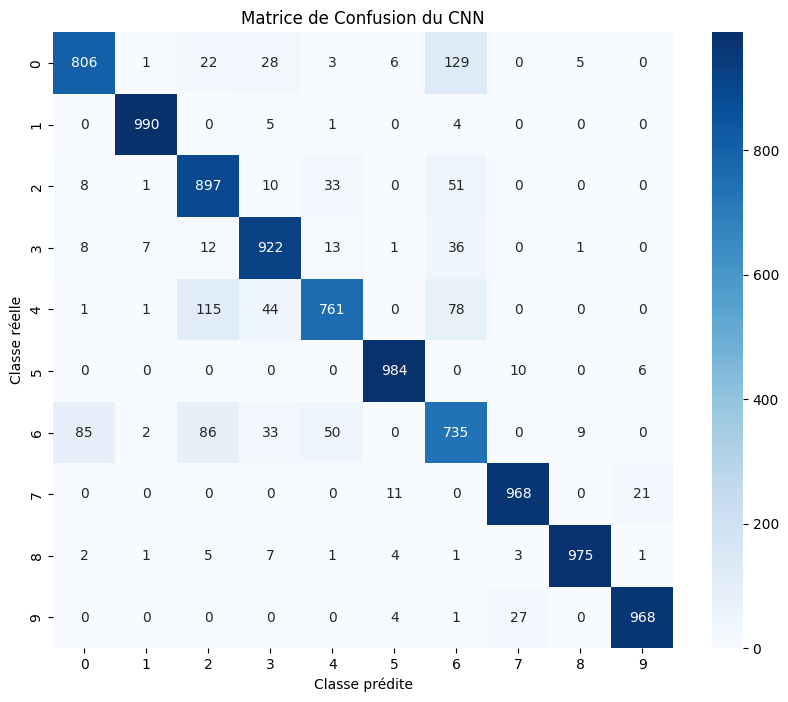

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mise en mode évaluation
modele_cnn.eval()
y_true = []
y_pred = []

# 2. Test sur l'ensemble de données non vues
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = modele_cnn(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Affichage du rapport complet
print("\n--- RÉSULTATS SUR LE JEU DE TEST (FASHION-MNIST) ---")
print(classification_report(y_true, y_pred))

# 4. Matrice de confusion pour l'interprétation scientifique
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion du CNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Partie 3 - RNN/LSTM

In [18]:
import torch
import numpy as np

# 1. Création d'une série temporelle artificielle (une onde sinusoïdale)
data = np.sin(np.linspace(0, 100, 1000))

# 2. Fonction pour créer des séquences (Windows)
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 10
X, y = create_sequences(data, SEQ_LENGTH)

# 3. Conversion en Tenseurs PyTorch
# Format attendu par RNN : (Batch_Size, Seq_Length, Input_Size)
X_tensor = torch.from_numpy(X).float().unsqueeze(-1)
y_tensor = torch.from_numpy(y).float()

print(f"Format des données d'entrée (X) : {X_tensor.shape}")
print(f"Format des données cibles (y) : {y_tensor.shape}")
print("✅ Données prêtes pour le RNN !")

Format des données d'entrée (X) : torch.Size([990, 10, 1])
Format des données cibles (y) : torch.Size([990])
✅ Données prêtes pour le RNN !


In [19]:
import torch.nn as nn

class MonLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(MonLSTM, self).__init__()
        # LSTM : couche récurrente
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Couche linéaire pour ramener la sortie du LSTM (taille hidden_size) vers une valeur unique
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x est de forme (Batch, Seq_Length, Input_Size)
        # out contient les sorties à chaque pas de temps
        # _ contient les états cachés (hidden states)
        out, _ = self.lstm(x)

        # On ne veut que la prédiction du dernier pas de temps (le futur)
        # out[:, -1, :] prend le dernier élément de la séquence
        out = self.fc(out[:, -1, :])
        return out

# Initialisation du modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = MonLSTM().to(device)
print("Modèle LSTM défini :", model_lstm)

Modèle LSTM défini : MonLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
import torch.optim as optim

# Préparation des données sur le device
X_train = X_tensor.to(device)
y_train = y_tensor.to(device)

# Outils d'optimisation
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.01)

# Boucle d'entraînement
epochs = 50
model_lstm.train()

print("\nDébut de l'entraînement LSTM...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass
    outputs = model_lstm(X_train)

    # Calcul de la perte
    loss = criterion(outputs.squeeze(), y_train)

    # Backward pass et mise à jour des poids
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | Perte (MSE) : {loss.item():.6f}")

print("\n✅ Entraînement terminé !")


Début de l'entraînement LSTM...
Époque [10/50] | Perte (MSE) : 0.140625
Époque [20/50] | Perte (MSE) : 0.011896
Époque [30/50] | Perte (MSE) : 0.008644
Époque [40/50] | Perte (MSE) : 0.002395
Époque [50/50] | Perte (MSE) : 0.001284

✅ Entraînement terminé !


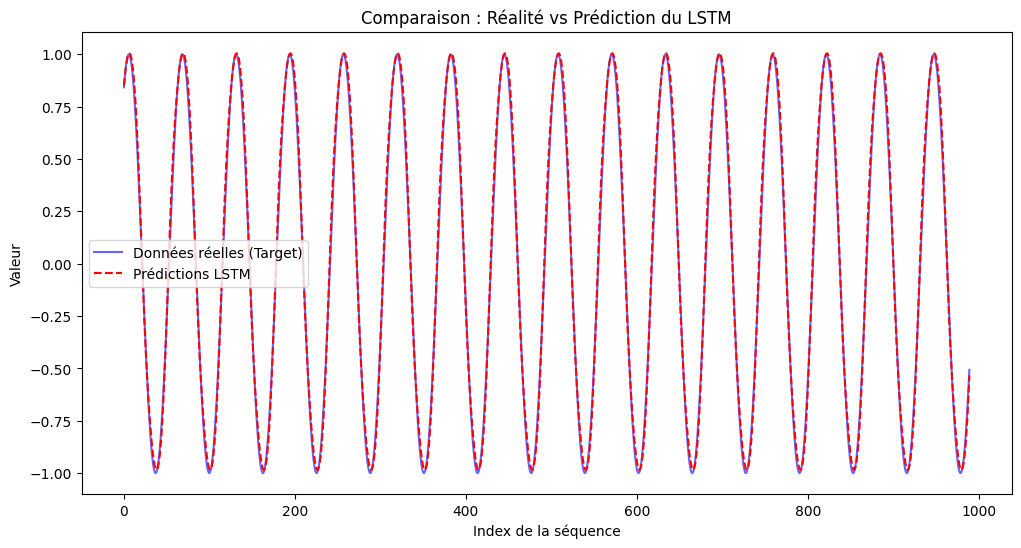

In [21]:
import matplotlib.pyplot as plt

# Passer en mode évaluation
model_lstm.eval()

# Faire les prédictions sur tout le dataset
with torch.no_grad():
    predictions = model_lstm(X_train).cpu().numpy()

# Tracer les résultats
plt.figure(figsize=(12, 6))
plt.plot(y_train.cpu().numpy(), label="Données réelles (Target)", color='blue', alpha=0.6)
plt.plot(predictions, label="Prédictions LSTM", color='red', linestyle='--')
plt.title("Comparaison : Réalité vs Prédiction du LSTM")
plt.legend()
plt.xlabel("Index de la séquence")
plt.ylabel("Valeur")
plt.show()